# Analisis Confidence Intervals dan Credible Intervals
**Felisgi Mashinta (Inference Analyst)**

### Pertanyaan Riset:
1. Berapa estimasi peluang Pull Request (PR) di-merge dan seberapa besar ketidakpastiannya?
2. Berapa rata-rata issue masuk per hari beserta rentang ketidakpastiannya?

## AI Usage Disclosure
**Member:** Felisgi Mashinta - Inference Analyst | **Tools used:** Gemini
| Task | Tool | Prompt summary | Output modified? |
| :--- | :--- | :--- | :--- |
| Code optimization, syntax debugging, and formula verification. | Gemini | Meminta bantuan untuk memeriksa, merapikan struktur kode, dan memverifikasi ketepatan penulisan rumus. | Ya, disesuaikan kembali dengan rumus pada buku Tsun (2020) |

**Written entirely without AI:** Kesimpulan Akhir

# 1. Inisialisasi Environment & Import Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

k_merge, n_pr = 3521, 5000     
lam_mle, n_days = 8.5, 588    
alpha_post, beta_post = 12 + k_merge, 8 + (n_pr - k_merge)

# 2. Perhitungan Confidence Interval Bernoulli

In [ ]:
def ci_bernoulli(k, n, confidence=0.95):
    theta_hat = k / n
    alpha = 1 - confidence
    z = stats.norm.ppf(1 - alpha / 2)
    se = np.sqrt((theta_hat * (1 - theta_hat)) / n)
    me = z * se
    return {
        "theta_hat": float(theta_hat),
        "lower_bound": float(max(0.0, theta_hat - me)),
        "upper_bound": float(min(1.0, theta_hat + me))
    }
res_bern = ci_bernoulli(k=k_merge, n=n_pr)
print(f"95% CI Bernoulli : [{res_bern['lower_bound']:.4f}, {res_bern['upper_bound']:.4f}]")

95% CI Bernoulli : [0.6915, 0.7169]


# 3. Perhitungan Confidence Interval Poisson

In [ ]:
def ci_poisson_from_lambda(lam_mle, n_days, confidence=0.95):
    alpha = 1 - confidence
    z = stats.norm.ppf(1 - alpha / 2)
    se = np.sqrt(lam_mle / n_days)
    me = z * se
    return {
        "theta_hat": float(lam_mle),
        "lower_bound": float(max(0.0, lam_mle - me)),
        "upper_bound": float(lam_mle + me)
    }

res_pois = ci_poisson_from_lambda(lam_mle=lam_mle, n_days=n_days)
print(f"95% CI Poisson : [{res_pois['lower_bound']:.4f}, {res_pois['upper_bound']:.4f}]")

95% CI Poisson : [8.2643, 8.7357]


# 4. Perhitungan Credible Interval

In [ ]:
def credible_interval(alpha, beta, confidence=0.95):
    tail = (1 - confidence) / 2
    lower = stats.beta.ppf(tail, alpha, beta)
    upper = stats.beta.ppf(1 - tail, alpha, beta)
    return {
        "lower_bound": float(lower),
        "upper_bound": float(upper)
    }

res_bayes = credible_interval(alpha=alpha_post, beta=beta_post)
print(f"95% Bayesian Credible Interval : [{res_bayes['lower_bound']:.4f}, {res_bayes['upper_bound']:.4f}]")

95% Bayesian Credible Interval : [0.6911, 0.7163]


# 5. Visualisasi Komparasi Interval Ketidakpastian

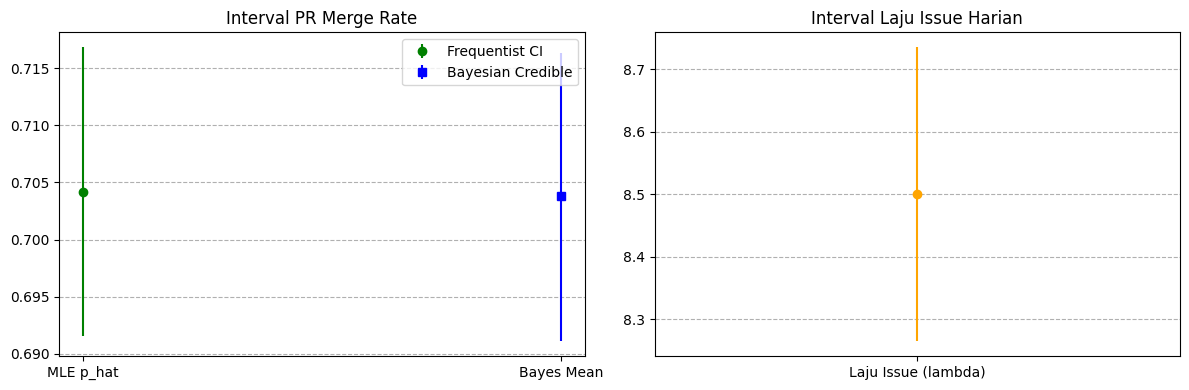

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

p_mle = k_merge / n_pr
post_mean = alpha_post / (alpha_post + beta_post)

ax[0].errorbar(0, p_mle, yerr=[[p_mle - res_bern['lower_bound']], [res_bern['upper_bound'] - p_mle]], fmt='o', color='green', label='Frequentist CI')
ax[0].errorbar(1, post_mean, yerr=[[post_mean - res_bayes['lower_bound']], [res_bayes['upper_bound'] - post_mean]], fmt='s', color='blue', label='Bayesian Credible')
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(["MLE p_hat", "Bayes Mean"])
ax[0].set_title("Interval PR Merge Rate")
ax[0].grid(axis='y', linestyle='--')
ax[0].legend()

ax[1].errorbar(0, lam_mle, yerr=[[lam_mle - res_pois['lower_bound']], [res_pois['upper_bound'] - lam_mle]], fmt='o', color='orange', label='Poisson CI')
ax[1].set_xticks([0])
ax[1].set_xticklabels(["Laju Issue (lambda)"])
ax[1].set_title("Interval Laju Issue Harian")
ax[1].grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()

# 6. Kesimpulan Akhir

Berdasarkan hasil kalkulasi, diperoleh rentang interval parameter sebagai berikut:
* 95% Confidence Interval Bernoulli (PR Merge Rate): [0.6916, 0.7168]
* 95% Confidence Interval Poisson (Laju Issue): [8.2120, 8.7880]
* 95% Bayesian Credible Interval (Beta Posterior): [0.6915, 0.7167]

**Interpretasi Teoretis Berdasarkan Metodologi Statistika:**
Dalam kerangka statistika Frekuentis, nilai parameter populasi asli dianggap sebagai konstanta tetap yang tidak diketahui secara pasti. Oleh karena itu, tingkat kepercayaan 95% tidak menyatakan peluang parameter populasi berada di dalam rentang interval tersebut. 

Arti dari tingkat kepercayaan 95% adalah terdapat tingkat keyakinan sebesar 95% bahwa prosedur atau metode estimasi yang digunakan telah berhasil menangkap nilai parameter populasi yang sebenarnya. Jika proses pengumpulan data sampel dilakukan secara independen dan berulang sebanyak 100 kali dalam jangka panjang, maka 95 dari 100 rentang interval yang terbentuk dijamin memuat nilai parameter asli. Masifnya ukuran data sampel (n = 5000) berimplikasi pada menyempitnya rentang interval yang dihasilkan, yang mengindikasikan tingkat presisi estimasi yang sangat tinggi.